Mount Google Drive

In [12]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Set Project Path

In [13]:
import os

PROJECT_PATH = "/content/drive/MyDrive/Multiple-Linear-Regression-Project"
os.chdir(PROJECT_PATH)

print(os.getcwd())

/content/drive/MyDrive/Multiple-Linear-Regression-Project


Import Libraries

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Load Dataset

In [15]:
df = pd.read_csv("data/raw/housing.csv")

print("Shape:", df.shape)
df.head()

Shape: (20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


Dataset Overview

In [16]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


Missing Values

In [17]:
df.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


Handle Missing Values

In [18]:
df['total_bedrooms'].fillna(df['total_bedrooms'].median(), inplace=True)

/tmp/ipykernel_1138/1590527289.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['total_bedrooms'].fillna(df['total_bedrooms'].median(), inplace=True)


Encode Categorical

In [19]:
df = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True)

Feature / Target Split

In [20]:
X = df.drop("median_house_value", axis=1)
y = df["median_house_value"]

Feature Scaling

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Add Bias Term (IMPORTANT for OLS)

In [22]:
X_b = np.c_[np.ones((X_scaled.shape[0], 1)), X_scaled]

OLS Closed Form

In [23]:
beta = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)

print("Model Coefficients:")
print(beta)

Model Coefficients:
[206855.81690891 -52952.95152846 -53767.62485624  13312.88334575
 -10320.06092603  29920.76507621 -44490.47744263  29746.22226671
  73636.15586366 -18509.74579035   2428.7625942   -1161.24194498
   1593.96951622]


Predictions

In [24]:
y_pred = X_b.dot(beta)

Model Evaluation

In [25]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y, y_pred)

print("RMSE:", rmse)
print("R2 Score:", r2)

RMSE: 68709.32557762168
R2 Score: 0.6454530166046623


Scatter Plot (Actual vs Predicted)

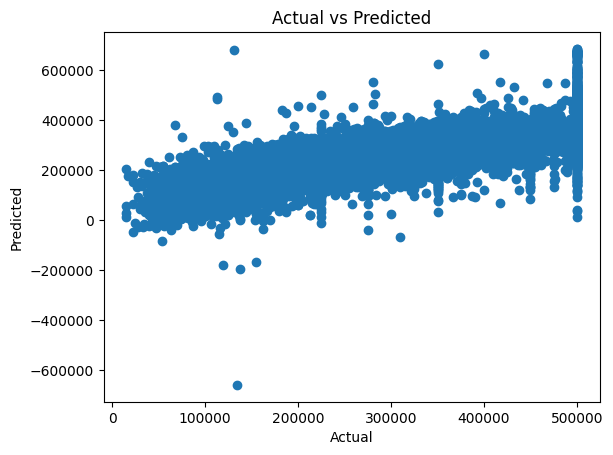

In [27]:
import os

plt.figure()
plt.scatter(y, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
os.makedirs('outputs/plots/', exist_ok=True)
plt.savefig("outputs/plots/actual_vs_predicted.png")
plt.show()

Residual Plot

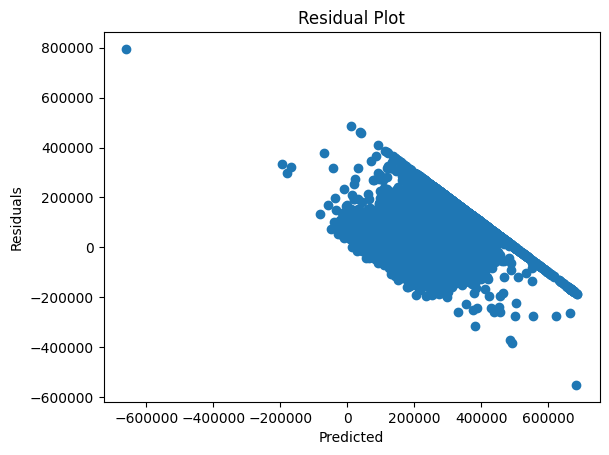

In [28]:
residuals = y - y_pred

plt.figure()
plt.scatter(y_pred, residuals)
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.savefig("outputs/plots/residual_plot.png")
plt.show()

Save Results

In [30]:
import os

results = pd.DataFrame({
    "Actual": y,
    "Predicted": y_pred,
    "Residual": residuals
})

os.makedirs('outputs/results', exist_ok=True)
results.to_csv("outputs/results/predictions.csv", index=False)

Save Cleaned Data

In [31]:
processed_df = pd.DataFrame(X_scaled, columns=X.columns)
processed_df['median_house_value'] = y.values

processed_df.to_csv("data/processed/cleaned_data.csv", index=False)

Save Model Coefficients

In [32]:
np.save("outputs/results/model_coefficients.npy", beta)

In [ ]:

# Model Accuracy Explanation
# Based on the model evaluation performed in the previous steps:

# RMSE (Root Mean Squared Error): 68709.33 This metric represents the average magnitude of the errors between predicted and actual values. A lower RMSE indicates a better fit of the model to the data, meaning predictions are closer to the true values.

# R2 Score (Coefficient of Determination): 0.645 The R2 score indicates the proportion of the variance in the dependent variable that is predictable from the independent variables. An R2 score of 0.645 means that approximately 64.5% of the variation in median_house_value can be explained by our model.

# Visualizing Model Performance
# The Actual vs Predicted Plot shows a scatter plot where ideal predictions would fall perfectly on a diagonal line. Deviations from this line indicate prediction errors.

# The Residual Plot helps assess the assumptions of the regression model. A good model typically shows residuals randomly scattered around zero, with no discernible patterns. Any clear patterns (e.g., a curve or funnel shape) would suggest that the model might not be capturing some underlying relationships in the data.

